# **Redes Neurais Recorrentes**
<font size=3>

As **redes neurais recorrentes** (RNNs) surgem como uma arquitetura fundamental para lidar com **dados sequenciais**, sendo especialmente relevantes em aplicações de Processamento de Linguagem Natural, onde o **contexto** e a **ordem das palavras** desempenham papel essencial para o entendimento do significado. Ao contrário das redes neurais tradicionais, que assumem que as entradas são independentes entre si, as **RNNs são capazes de preservar informações de entradas anteriores**, permitindo que o modelo capture dependências temporais e contextuais em uma sequência de texto.


## **1. Camadas recorrentes para dados textuais:**
<font size=3>

Quando trabalhamos com texto, lidamos naturalmente com **sequências de palavras**. O significado de uma palavra em uma frase pode depender diretamente das palavras anteriores. Por exemplo:

> “**Ele comprou o livro porque *gostava* de ler.**”

A palavra "gostava" só faz sentido no contexto anterior ("comprou o livro"). Portanto, modelos de PLN precisam **lembrar o que veio antes** para tomar boas decisões.

### **1.1 O Conceito de _memória_ em sequências:**
<font size=3>

Para entender RNNs, precisamos primeiro lembrar da limitação fundamental das redes neurais densas (*feedforward*) que vimos até agora: elas são **amnésicas**.

Em uma rede densa comum, se você passar a frase *"O filme é ótimo"*, a rede processa essa entrada e gera uma saída. Se logo em seguida você passar *"Mas o final é ruim"*, a rede processa essa nova entrada **sem ter qualquer lembrança** da anterior. Para ela, são dois eventos independentes e isolados no universo. Não há continuidade.

<font size=3>

As RNNs quebram esse paradigma introduzindo um **loop de feedback**. Elas processam a informação passo a passo (*token* por *token*), mas com um diferencial crucial:

> A saída de um passo anterior é **reintroduzida** na rede junto com a nova entrada do passo atual.

Essa informação reintroduzida é o que chamamos tecnicamente de **estado oculto** (*hidden state*) ou $h_t$. Pense no estado oculto como um **resumo vetorial de tudo o que aconteceu até agora**, uma *memória latente*.

<font size=3>

Imagine que a rede está lendo uma crítica de cinema palavra por palavra:

1.  **Entrada:** "Não" $\rightarrow$ **Estado:** [Negatividade detectada]
2.  **Entrada:** "gostei" + **Estado Anterior** [Negatividade] $\rightarrow$ **Novo Estado:** [Sentimento muito negativo confirmado]
3.  **Entrada:** "de nada" + **Estado Anterior** [Muito negativo] $\rightarrow$ **Novo Estado:** [Sentimento negativo extremo consolidado]

Diferente da rede densa, a RNN não olha para "gostei" isoladamente (o que seria positivo). Ela olha para "gostei" **contextualizada** pelo estado anterior que continha a informação do "Não".

É essa persistência do estado ($h_t$) ao longo do eixo temporal ($t$) que permite à rede conectar o início de uma frase ao seu final, simulando o processo cognitivo humano de leitura.

## **2. Camada recorrente simples:**
<font size=3>

Agora, vamos compreender o funcionamento básico de uma **camada recorrente simples (_SimpleRNN_)**. Diferente das camadas densas — onde cada entrada tem seu próprio peso exclusivo — a camada recorrente processa a sequência inteira reutilizando a **mesma célula** repetidamente. Imagine uma linha de montagem onde cada palavra passa pela mesma máquina. Essa máquina tem uma "memória de trabalho" que é atualizada a cada passo.

### **2.1 Estrutura matemática:**
<font size=3>

Matematicamente, a SimpleRNN calcula o novo estado oculto ($\mathbf{h}_t$) combinando duas fontes de informação: o que aconteceu agora ($\mathbf{x}_t$) e o que aconteceu antes ($\mathbf{h}_{t-1}$).

A equação fundamental é dada por

$$
\mathbf{h}_t = \tanh(\underbrace{\mathbf{W}_x \cdot \mathbf{x}_t}_{\text{Informação Atual}} + \underbrace{\mathbf{W}_h \cdot \mathbf{h}_{t-1}}_{\text{Memória Passada}} + \mathbf{b}) \, ,
$$
onde:
1. **$\mathbf{x}_t$ (Input Atual):** O vetor da palavra que estamos lendo agora (ex: "filme").
2. **$\mathbf{h}_{t-1}$ (Estado Anterior):** O vetor que resume a frase lida até o passo anterior (ex: contexto de "Eu", "não", "gostei", "do").
3. **$\mathbf{W}_x$ (Pesos de Entrada):** Determina a importância da nova palavra.
4. **$\mathbf{W}_h$ (Pesos Recorrentes):** Determina o quanto devemos "lembrar" ou "esquecer" do passado. **Aqui reside a memória de curto prazo.**
5. **$\tanh$ (Função de Ativação):** Transforma o resultado para o intervalo $[-1,\, 1]$. Isso é vital para manter os valores controlados, já que estamos multiplicando matrizes repetidamente (evitando que os números cresçam ao infinito).

> **Observe** que $\mathbf{W}_x$ e $\mathbf{W}_h$ não têm o subscrito $t$. Isso significa que **os pesos são constantes durante toda a frase**. A rede usa a mesma "regra" para processar a primeira e a última palavra. Isso permite tratar sequências de qualquer tamanho.

<br>
<details>
<summary>Análise dimensional:</summary>

Vamos desenvolver a análise dimensional da equação do SimpleRNN. Para isso, iremos simplicar a notação das dimensões:
\begin{align}
    T &\equiv \text{max-len} \\
    E &\equiv \text{embed-dim} \\
    H &\equiv \text{hidden-dim}
\end{align}
onde $\text{hidden-dim}$ é a **dimensão do estado oculto**.

**Uma** sentença vetorizada é definida por $\mathbf x \in \mathbb R^{E,\, T}$, tal que, em dada posição $t$ da sequência, $\mathbf x_t \in \mathbb R^{E,\, 1} \equiv \mathbb R^E$. Sendo assim, a fim de considerar a dimensão do estado oculto $H$ no produto escalar $\mathbf W_x \cdot \mathbf x_t$, devemos escrever
\begin{align}
    \mathbf W_x\cdot \mathbf x_t &\in \mathbb R^{H,\,E}\times\mathbb R^{E} = \mathbb R^H \;\rightarrow\; \mathbf W_x \in \mathbb R^{H,\,E} \, ,\\\\
    \therefore\, \mathbf h_t &\in \mathbb R^{H} \;\rightarrow\; \mathbf h \in \mathbb R^{H,\, T} \, .
\end{align}

>**Observação:** aqui, utilizamos a definição algébrica formal. No entanto, algumas bibliotecas, como $\text{TensorFlow}$, podem aderir a definições alternativas de implementações, como o produto escalar $\mathbf x_t\cdot \mathbf W_x$, o que pode leva a $\mathbf h \in \mathbb R^{T,\, H}$.

Aplicando os resultados na equação, temos que
\begin{align}
    &\underbrace{\mathbf W_x\cdot \mathbf x_t}_{\mathbb R^H} + \mathbf W_h\cdot \underbrace{\mathbf h_{t-1}}_{\mathbb R^H} + \mathbf b \in \mathbb R^H \, ,\\\\
    &\therefore\;\mathbf W_h \in \mathbb R^{H,\,H} \, ,\;\; \mathbf b \in \mathbb R^H \, .
\end{align}

<br>

Em resumo, temos:
- $\mathbf x \in \mathbb R^{E,\, T} \;\rightarrow\; \mathbf x_t \in \mathbb R^E$
- $\mathbf h \in \mathbb R^{H,\, T} \;\rightarrow\; \mathbf h_t \in \mathbb R^H$
- $\mathbf W_x \in \mathbb R^{H,\,E}$
- $\mathbf W_h \in \mathbb R^{H,\,H}$
    
</details>
<br>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

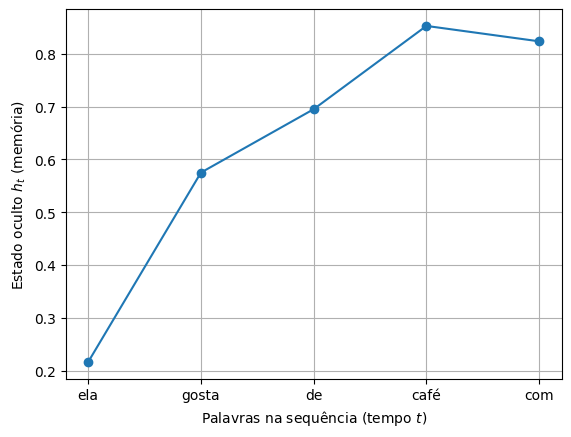

In [3]:
# representações numéricas de cada token:
representacoes = {"ela": 0.2,
                  "gosta": 0.6,
                  "de": 0.4,
                  "café": 0.9,
                  "com": 0.5}

# parâmetros da "RNN simples":
# (para fins didáticos as matrizes e vetores serão representados por escalares)
W_x = 0.6  # peso para entrada
W_h = 0.9  # peso para estado anterior
b = 0.1    # viés
h_t = 0    # estado oculto inicial

# processando a sequência:
entrada = ["ela", "gosta", "de", "café", "com"]
hidden_states = []

for palavra in entrada:
    x_t = representacoes[palavra]

    h_t = np.tanh(W_x * x_t + W_h * h_t + b)

    hidden_states.append(h_t)

plt.plot(hidden_states, marker='o')
plt.xticks(range(len(entrada)), entrada)
plt.xlabel("Palavras na sequência (tempo $t$)")
plt.ylabel("Estado oculto $h_t$ (memória)")
plt.grid()
plt.show()

<font size=3>
    
Neste gráfico, vemos como o **estado da oculto ($\mathbf h_t$)** se transforma à medida que novas palavras são processadas. O valor do estado oculto final, após "com", representa uma **síntese da sequência completa até esse ponto**.

Esse vetor $\mathbf h_t$ é então utilizado pela RNN para prever **a próxima palavra**. Se a memória foi bem construída, ela carrega indícios de que a sequência falava de algo como "café com...", permitindo prever corretamente palavras como "leite".

Para uma **tarefa de classificação**, por exemplo, usamos como saída o último estado oculto $\mathbf{h}_T$.

### **2.2 Exemplo prático:**
<font size=3>

Vamos comparar diferentes arquiteturas, ao longo da aula, com o *dataset* de revisão de filmes [IMDB](https://keras.io/api/datasets/imdb/).

In [4]:
import keras
from keras import layers
from keras.datasets.imdb import load_data
from tensorflow.keras.utils import pad_sequences

In [5]:
# definindo hiperparâmetros:
vocab_size = 5000
max_len = 256
embed_dim = 32

# importando os dados (textos já indexados):
(X1, y1), (X2, y2) = load_data(maxlen=max_len, num_words=vocab_size)

# divisão melhor dos dados:
X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

n_train = int(0.8*X.size)
X_train = X[:n_train]
y_train = y[:n_train]

# nesta aula, iremos apenas realizar treinamento com validação:
X_val = X[n_train:]
y_val = y[n_train:]

# preenchendo (padding) com 0 sentenças de tamanho menor que max-len:
X_train = pad_sequences(X_train, maxlen=max_len)
X_val = pad_sequences(X_val, maxlen=max_len)

print(f"X-train:{X_train.shape}, y-train:{y_train.shape}")
print(f"X-val:{X_val.shape}, y-val:{y_val.shape}")

del X, X1, X2
del y, y1, y2

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X-train:(28207, 256), y-train:(28207,)
X-val:(7052, 256), y-val:(7052,)


In [6]:
x_in = keras.Input((max_len, ))

x = layers.Embedding(vocab_size, embed_dim)(x_in)

x = layers.SimpleRNN(units=100, return_sequences=False)(x) # retorna apenas o último estado oculto

x = layers.Dense(20, activation="relu")(x)

x_out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        13,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,341 (684.93 KB)

 Trainable params: 175,341 (684.93 KB)

 Non-trainable params: 0 (0.00 B)

<font size=3>

>**Observação:** como nossa tarefa é uma classificação **binária**, e a variável alvo $y$ apresenta apenas 0s e 1s, iremos considerar na camada de saída um único neurônio com função de ativação *sigmoid*. Vale lembrar que, para classificações com acima de duas classes, **devemos** utilizar na última camada o número de neurônios igual ao número de classes e a função de activação *softmax*.

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - acc: 0.5317 - loss: 0.6888 - val_acc: 0.5905 - val_loss: 0.6681
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.6563 - loss: 0.6131 - val_acc: 0.5783 - val_loss: 0.7873
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.7191 - loss: 0.5482 - val_acc: 0.7653 - val_loss: 0.4812
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - acc: 0.8219 - loss: 0.3961 - val_acc: 0.8025 - val_loss: 0.4581
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.8701 - loss: 0.3133 - val_acc: 0.8481 - val_loss: 0.3482


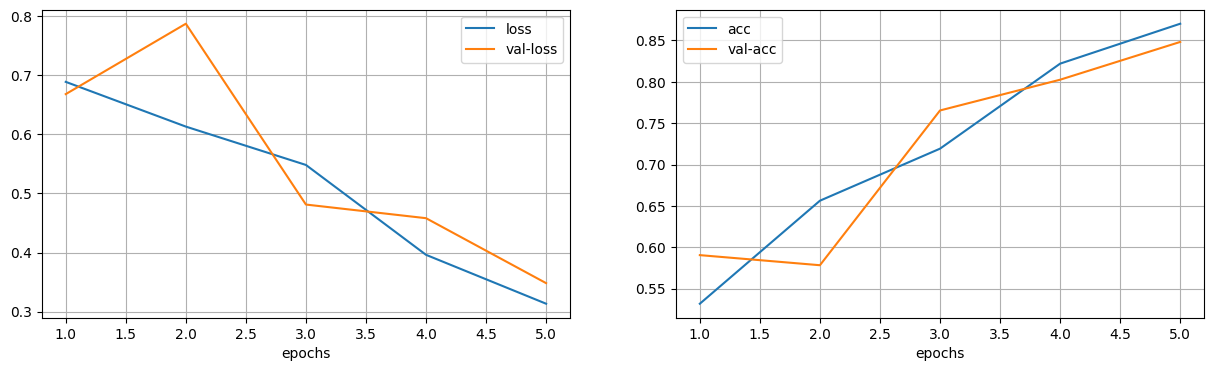

In [7]:
def train(model):

    # compilando o modelo:
    model.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["acc"])

    # treinando o modelo:
    report = model.fit(x=X_train, y=y_train, validation_data=[X_val, y_val], batch_size=256, epochs=5)

    # visualizando a performance:
    loss = report.history['loss']
    val_loss = report.history['val_loss']

    acc = report.history['acc']
    val_acc = report.history['val_acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(15,4))

    ax[0].plot(epochs, loss, label="loss")
    ax[0].plot(epochs, val_loss, label="val-loss")

    ax[1].plot(epochs, acc, label="acc")
    ax[1].plot(epochs, val_acc, label="val-acc")

    for i in range(2):
        ax[i].set_xlabel("epochs")
        ax[i].legend()
        ax[i].grid()

    plt.show()

train(model)

### **2.3 Empilhamento de camadas recorrentes:**
<font size=3>

Para aumentar a capacidade de abstração do modelo, podemos criar **Deep RNNs** empilhando múltiplas camadas recorrentes.

No entanto, existe um detalhe estrutural importante: por padrão, uma camada recorrente retorna apenas o **último estado oculto** ($\mathbf{h}_T$), descartando os estados intermediários. Para que uma segunda camada recorrente possa processar a sequência, a primeira camada precisa retornar a **sequência completa de estados ocultos** $(\mathbf{h}_1, \mathbf{h}_2, \dots, \mathbf{h}_T)$.

Neste caso, a saída deixa de ser um vetor 2D e passa a ser um tensor 3D com formato `(batch_size, time_steps, units)`, estruturalmente idêntico à saída de uma camada de *embedding*. Isso permite conectar a saída de uma RNN diretamente na entrada de outra.


In [8]:
x_in = keras.Input((max_len, ))

x = layers.Embedding(vocab_size, embed_dim)(x_in)

x = layers.SimpleRNN(units=100, return_sequences=True)(x)

x = layers.SimpleRNN(units=100, return_sequences=False)(x)

x = layers.Dense(20, activation="relu")(x)

x_out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 256, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 256, 100)       │        13,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,441 (763.44 KB)

 Trainable params: 195,441 (763.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - acc: 0.5060 - loss: 0.6949 - val_acc: 0.4895 - val_loss: 0.6956
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - acc: 0.5191 - loss: 0.7162 - val_acc: 0.5094 - val_loss: 0.7010
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.5025 - loss: 0.7391 - val_acc: 0.4895 - val_loss: 0.6971
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - acc: 0.5087 - loss: 0.7006 - val_acc: 0.4894 - val_loss: 0.6977
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.5091 - loss: 0.6975 - val_acc: 0.4895 - val_loss: 0.7055


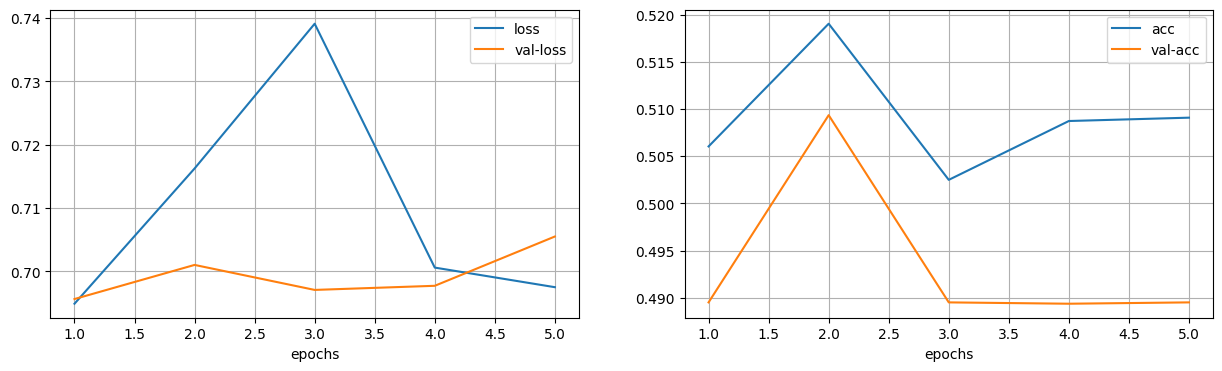

In [9]:
train(model)

<font size=3>
   
>**Observação:** empilhar camadas recorrentes aumenta drasticamente o número de parâmetros e o tempo de treinamento. Em muitos problemas de classificação de texto simples, uma única camada bem ajustada é suficiente. O empilhamento destas camada brilham em tarefas complexas como tradução automática ou modelagem de linguagem generativa.

## **3. Camada LSTM:**
<font size=3>

A **SimpleRNN** consegue capturar dependências curtas em uma sequência, mas enfrenta dificuldades quando precisa aprender **relações de longo prazo**. Isso ocorre por causa do **problema do gradiente desvanecente** (*vanishing gradient*), que impede que informações distantes sejam propagadas eficazmente durante o treinamento.

<font size=3>
    
A **LSTM** (*Long Short-Term Memory*) resolve isso introduzindo uma "via expressa" para a informação: o **Estado da Célula** (*Cell State*, ou $\mathbf{c}_t$). Diferente do estado oculto, que é reescrito a cada passo, o estado da célula atravessa a rede sofrendo apenas interações lineares menores, o que preserva o gradiente.

Para gerenciar essa memória, a LSTM utiliza **3 portas (_gates_)** que regulam o fluxo de informação: *input gate* $\mathbf{i}_t$, *forget gate* $\mathbf{f}_t$, e o *output gate* $\mathbf{o}_t$.

### **3.1 Estrutura matemática:**
<font size=3>

Nesta formulação, distinguimos explicitamente as matrizes de peso:
* $\mathbf{W}$: Pesos aplicados à entrada atual ($\mathbf{x}_t$).
* $\mathbf{U}$: Pesos aplicados ao estado oculto anterior ($\mathbf{h}_{t-1}$).
* $\mathbf{b}$: Vetor de viés (*bias*).

O processamento ocorre em 4 etapas lógicas, onde a LSTM segue o princípio de "limpar para organizar". Primeiro decidimos o que jogar fora da memória antiga (para liberar espaço), e só depois decidimos o que adicionar de novo.

1. **Porta de esquecimento (_forget gate_):**
Decide qual informação do estado da célula anterior ($\mathbf{c}_{t-1}$) deve ser descartada.

$$
\mathbf{f}_t = \sigma(\mathbf{W}_f \cdot \mathbf{x}_t + \mathbf{U}_f \cdot \mathbf{h}_{t-1} + \mathbf{b}_f)
$$

> *Saída:* Um vetor entre 0 (esquecer tudo) e 1 (manter tudo).

2. **Porta de entrada e candidato (_input gate_):**
Decide qual nova informação será armazenada. Primeiro, a porta de entrada ($\mathbf{i}_t$) seleciona os valores a serem atualizados. Em seguida, criamos um vetor de novos candidatos ($\tilde{\mathbf{c}}_t$).

$$
\begin{aligned}
\mathbf{i}_t &= \sigma(\mathbf{W}_i \cdot \mathbf{x}_t + \mathbf{U}_i \cdot \mathbf{h}_{t-1} + \mathbf{b}_i) \\
\tilde{\mathbf{c}}_t &= \tanh(\mathbf{W}_c \cdot \mathbf{x}_t + \mathbf{U}_c \cdot \mathbf{h}_{t-1} + \mathbf{b}_c)
\end{aligned}
$$

3. **Atualização do estado da célula (_cell state update_):**
Aqui ocorre a mágica. O novo estado ($\mathbf{c}_t$) é a soma da memória antiga filtrada pelo esquecimento, mais a nova memória filtrada pela entrada.

$$
\mathbf{c}_t = \underbrace{\mathbf{f}_t \odot \mathbf{c}_{t-1}}_{\text{O que mantemos}} + \underbrace{\mathbf{i}_t \odot \tilde{\mathbf{c}}_t}_{\text{O que aprendemos}}
$$

> **Nota:** A operação de **soma** (+) é fundamental, pois cria um caminho onde o gradiente pode fluir sem ser excessivamente multiplicado, mitigando o desvanecimento.

4. **Porta de saída e estado oculto (_output gate_):**
Por fim, decidimos o que será exposto como saída (o novo estado oculto $\mathbf{h}_t$). O estado oculto é uma versão filtrada e normalizada do estado da célula.

$$
\begin{aligned}
\mathbf{o}_t &= \sigma(\mathbf{W}_o \cdot \mathbf{x}_t + \mathbf{U}_o \cdot \mathbf{h}_{t-1} + \mathbf{b}_o) \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t)
\end{aligned}
$$

<br>

**Nas equações temos:**
- $\sigma$ : função de ativação — geralmente a *sigmoid*;
- $\odot$ : produto *element wise* (elemento a elemento).


<font size=3>
    
O uso dessas **portas** faz com que a LSTM **preserve informações relevantes** por períodos mais longos na sequência. Isso é útil em frases como:

> “Embora estivesse chovendo, ele saiu para correr porque estava treinando para uma maratona.”

Modelos simples esquecem rapidamente que **“ele”** está treinando. A LSTM é capaz de manter esse contexto útil até o final.

In [10]:
x_in = keras.Input((max_len, ))

x = layers.Embedding(vocab_size, embed_dim)(x_in)

x = layers.LSTM(units=100, return_sequences=False)(x)

x = layers.Dense(20, activation="relu")(x)

x_out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 256, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        53,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,241 (840.79 KB)

 Trainable params: 215,241 (840.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - acc: 0.7599 - loss: 0.4848 - val_acc: 0.8473 - val_loss: 0.3407
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.8916 - loss: 0.2659 - val_acc: 0.8942 - val_loss: 0.2544
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - acc: 0.9112 - loss: 0.2294 - val_acc: 0.8908 - val_loss: 0.2693
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.9178 - loss: 0.2109 - val_acc: 0.8938 - val_loss: 0.2623
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - acc: 0.9168 - loss: 0.2110 - val_acc: 0.8912 - val_loss: 0.2715


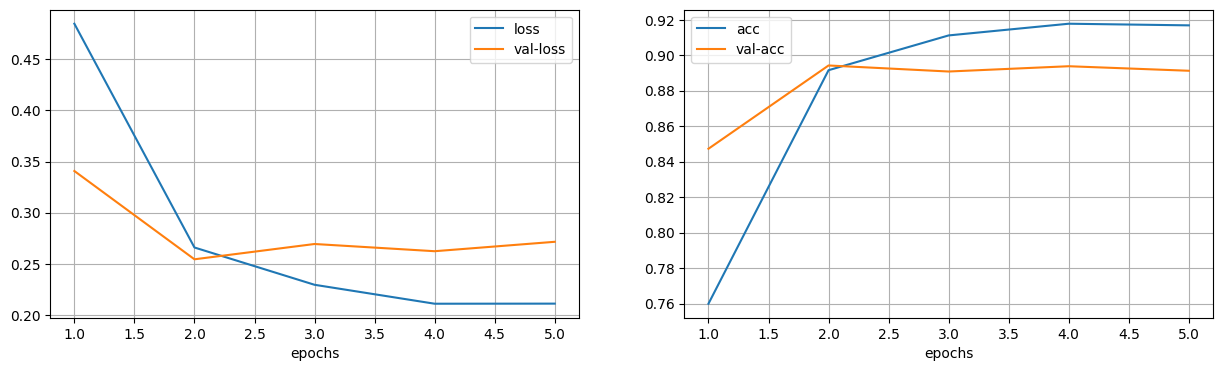

In [11]:
train(model)

## **4. Camada GRU:**
<font size=3>

A **GRU** (*Gated Recurrent Unit*) foi proposta por Cho et al. (2014) como uma versão mais simples da LSTM. Ela busca o **mesmo objetivo** — capturar dependências de longo prazo em sequências — mas com uma estrutura mais enxuta, com **menos parâmetros e menor custo computacional**.


<font size=3>

Em vez de três portas como na LSTM, a GRU possui apenas duas:
* **Porta de atualização** ($\mathbf z_t$);
* **Porta de reinicialização** ($\mathbf r_t$).

E ela **não possui um estado de célula separado** — onde em LSTM é dado por $\mathbf h_t$ e $\mathbf c_t$ — tudo é incorporado no estado oculto $\mathbf{h}_t$.

### **4.1 Estrutura matemática:**
<font size=3>

O fluxo de informação na GRU ocorre através de dois portões e um cálculo de candidato:

1. **Porta de atualização (_update gate_):**
Funciona como uma "balança" entre o passado e o presente. Ela decide quanto da memória antiga será mantida versus quanto da nova informação será escrita.

$$
\mathbf{z}_t = \sigma(\mathbf{W}_z \cdot \mathbf{x}_t + \mathbf{U}_z \cdot \mathbf{h}_{t-1} + \mathbf{b}_z)
$$

2. **Porta de reinicialização (_reset gate_):**
Decide o quanto do passado é importante para calcular a *nova proposta* de memória. Se $\mathbf{r}_t \approx 0$, a rede ignora o passado, permitindo que ela "reinicie" sua leitura baseada apenas na palavra atual.

$$
\mathbf{r}_t = \sigma(\mathbf{W}_r \cdot \mathbf{x}_t + \mathbf{U}_r \cdot \mathbf{h}_{t-1} + \mathbf{b}_r)
$$

3. **Candidato ao estado oculto:**
Aqui calculamos a nova informação proposta ($\tilde{\mathbf{h}}_t$).
Observe um detalhe crucial: a porta de reinicialização ($\mathbf{r}_t$) é aplicada ao estado anterior **antes** da multiplicação pela matriz de pesos recorrentes $\mathbf{U}_h$.

$$
\tilde{\mathbf{h}}_t = \tanh(\mathbf{W}_h \cdot \mathbf{x}_t + \mathbf{U}_h \cdot (\mathbf{r}_t \odot \mathbf{h}_{t-1}) + \mathbf{b}_h)
$$

4. **4. Atualização final do estado oculto:**
O novo estado $\mathbf{h}_t$ é uma interpolação linear controlada pela porta de atualização $\mathbf{z}_t$.

$$
\mathbf{h}_t = \underbrace{(1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1}}_{\text{Memória mantida}} + \underbrace{\mathbf{z}_t \odot \tilde{\mathbf{h}}_t}_{\text{Nova memória}}
$$


In [12]:
x_in = keras.Input((max_len, ))

x = layers.Embedding(vocab_size, embed_dim)(x_in)

x = layers.GRU(units=100, return_sequences=False)(x)

x = layers.Dense(20, activation="relu")(x)

x_out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 256, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,241 (790.00 KB)

 Trainable params: 202,241 (790.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.6815 - loss: 0.5952 - val_acc: 0.8409 - val_loss: 0.3775
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - acc: 0.8649 - loss: 0.3202 - val_acc: 0.8687 - val_loss: 0.3107
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - acc: 0.9009 - loss: 0.2521 - val_acc: 0.8890 - val_loss: 0.2716
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - acc: 0.9039 - loss: 0.2426 - val_acc: 0.8895 - val_loss: 0.2699
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - acc: 0.9145 - loss: 0.2240 - val_acc: 0.8870 - val_loss: 0.2752


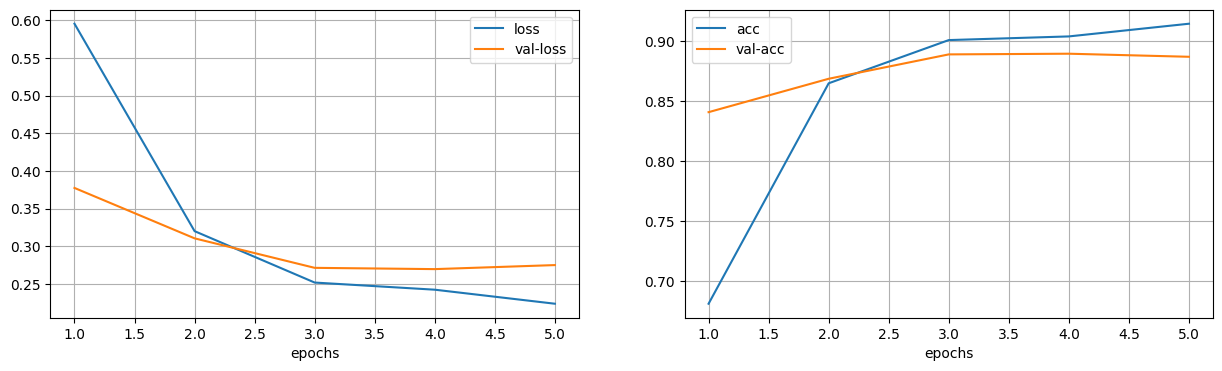

In [13]:
train(model)

## **5. Bidirecionalidade:**
<font size=3>
    
Até o momento, nossas redes processaram o texto de forma linear (esquerda para a direita). Embora arquiteturas como LSTM e GRU melhorem a memória, elas ainda sofrem com um "gargalo de informação" em **sequências longas**.

<font size=3>

Conforme a rede avança na leitura de um parágrafo longo, as informações do início (os primeiros tokens) tendem a se diluir ou perder relevância ("esquecimento"), pois o vetor de estado precisa comprimir cada vez mais contexto.

A **Bidirecionalidade** resolve este problema duplicando a arquitetura de processamento:
1. Uma camada lê a sequência no sentido original (*forward*).
2. Uma segunda camada lê a sequência de trás para frente (*backward*).

Ao concatenar os resultados de ambas as direções, garantimos que **todas as partes da sentença** (início, meio e fim) tenham uma representação rica e imediata, evitando que *features* cruciais do começo do texto sejam esquecidas ao final do processamento.

In [14]:
x_in = keras.Input((max_len, ))

x = layers.Embedding(vocab_size, embed_dim)(x_in)

layer = layers.GRU(units=100, return_sequences=False)

x = layers.Bidirectional(layer, merge_mode="concat")(x)

x_out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 256, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,601 (939.85 KB)

 Trainable params: 240,601 (939.85 KB)

 Non-trainable params: 0 (0.00 B)

<font size=3>

**Observação:** o padrão da variável `merge_mode` do Keras é concatenar os vetores (colocar um ao lado do outro), o que preserva mais informação, mas dobra a dimensionalidade. Existem outros modos como 'sum' (somar), que preserva a dimensão, mas são menos usados.


## **6. Comparações entre tipos de camadas:**
<font size=3>

Para consolidar o conhecimento, vamos comparar as três arquiteturas sob a ótica da engenharia de modelos. Observe que não existe "a melhor" camada absoluta, mas sim a mais adequada para as restrições do seu projeto (memória, tempo de treino e tamanho do dataset).

<font size=3>

| Característica | SimpleRNN | LSTM (Long Short-Term Memory) | GRU (Gated Recurrent Unit) |
| :--- | :--- | :--- | :--- |
| **Mecânica Interna** | Loop simples (multiplicação de matriz) | Complexa (3 Portões + Estado de Célula) | Simplificada (2 Portões) |
| **Portas (Gates)** | Nenhuma | 3: Entrada (*Input*), Esquecimento (*Forget*), Saída (*Output*) | 2: Atualização (*Update*), Reinicialização (*Reset*) |
| **Fluxo de Gradiente** | Instável (desaparece em sequências longas) | Estável (via caminho aditivo no *Cell State*) | Estável (similar à LSTM) |
| **Complexidade de Parâmetros** | $1\times$ (Base) | $\approx 4\times$ (4 conjuntos de pesos internos) | $\approx 3\times$ (3 conjuntos de pesos internos) |
| **Memória de Longo Prazo** | Inexistente (viés recência forte) | Excelente (controlada explicitamente) | Boa (mas acopla o esquecimento à nova entrada) |
| **Velocidade de Treino** | Muito Rápida | Lenta (muitas operações por passo) | Moderada (converge mais rápido que LSTM) |
| **Principal Vulnerabilidade** | **Vanishing Gradient** (impede aprendizado) | **Overfitting** em poucos dados e **Custo Computacional** | **Representatividade** em tarefas muito complexas |
| **Aplicação Ideal** | Apenas para fins didáticos | Datasets grandes, dependências complexas e longas | Datasets médios/pequenos, dispositivos móveis/edge |

### __Referências:__
<font size=3>
    
 - **(6.2):** [Deep Learning with Python](https://books.google.com.br/books/about/Deep_Learning_with_Python.html?id=Yo3CAQAACAAJ&redir_esc=y).
   